# Logistic Regression from Scratch 🧬

In this notebook, we move from regression to **classification**. We will implement **Logistic Regression**, the cornerstone of binary classification, using only `numpy`.

## 📖 Theoretical Background

Unlike linear regression, which predicts continuous values, logistic regression predicts the probability that a given input belongs to a specific class (usually 0 or 1).

### 1. The Sigmoid Function
To map any real-valued number into a probability between 0 and 1, we use the **Sigmoid function**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 2. The Hypothesis
The model computes a linear combination of inputs and then applies the sigmoid function:
$$z = Xw + b$$
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-(Xw + b)}}$$

### 3. The Cost Function (Log Loss / Binary Cross-Entropy)
We cannot use MSE for logistic regression because the resulting cost function would be non-convex. Instead, we use **Log Loss**:
$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$$

### 4. Gradient Descent
Surprisingly, the gradients for Logistic Regression look identical to those for Linear Regression (though $\hat{y}$ is calculated differently):
$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T(\hat{y} - y)$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum(\hat{y} - y)$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            # 1. Forward Pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # 2. Compute Loss (Log Loss)
            # Add a small epsilon to avoid log(0)
            epsilon = 1e-15
            loss = - (1 / n_samples) * np.sum(y * np.log(y_predicted + epsilon) + (1 - y) * np.log(1 - y_predicted + epsilon))
            self.loss_history.append(loss)

            # 3. Compute Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # 4. Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_prob(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted_cls = [1 if i > threshold else 0 for i in self.predict_prob(X)]
        return np.array(y_predicted_cls)

## 🧪 Data Generation and Training

In [3]:
# Generate classification data
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                           n_informative=2, random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Train model
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Classification Accuracy: {accuracy * 100:.2f}%")

Classification Accuracy: 90.00%


## 📊 Visualization

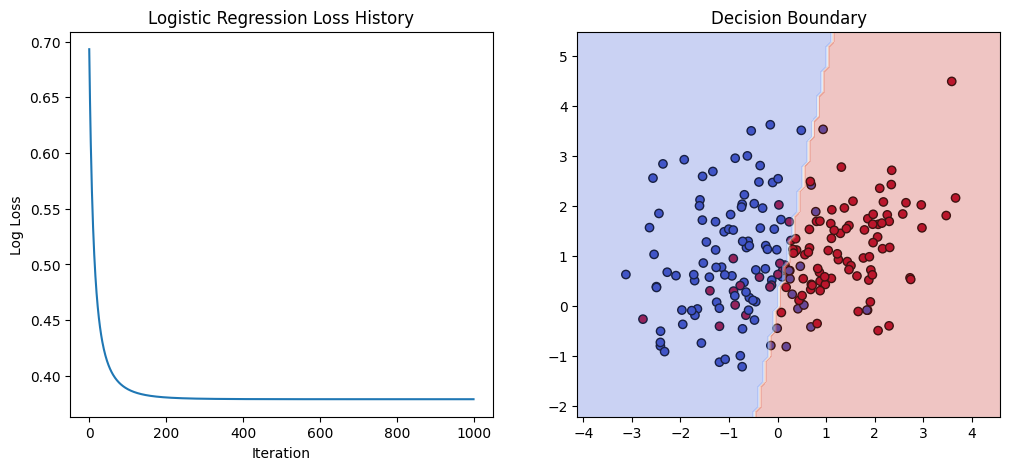

In [4]:
plt.figure(figsize=(12, 5))

# Plot Loss History
plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.title("Logistic Regression Loss History")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")

# Plot Decision Boundary
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")

# Create a mesh grid to plot decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.title("Decision Boundary")
plt.show()